In [14]:
#Uncomment if running for the first time
!pip install -q lightgbm catboost imbalanced-learn joblib

In [15]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline as SkPipeline

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

from catboost import CatBoostClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from google.colab import drive

drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
PROJECT_DIR = "/content/drive/MyDrive/Ghana_Dropout_Project"

MODEL_DIR = f"{PROJECT_DIR}/models"

RESULT_DIR = f"{PROJECT_DIR}/results"

FIGURE_DIR = f"{PROJECT_DIR}/figures"

DATA_DIR = f"{PROJECT_DIR}/data"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

In [17]:
# Same source file Notebook 4 used, so the train/test split below is
# reproducible and directly comparable to the baseline results.
df = pd.read_csv(f"{PROJECT_DIR}/cleaned_data.csv")

print(df.shape)
df.head()

baseline_results = pd.read_csv(f"{RESULT_DIR}/baseline_results.csv")

print("Baseline results loaded:", baseline_results.shape)
display(baseline_results)

TARGET = "dropout_label"

X = df.drop(columns=[TARGET])
y = df[TARGET]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()

categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric:", len(numeric_features))
print("Categorical:", len(categorical_features))


(1000, 41)
Baseline results loaded: (6, 7)


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Decision Tree,0.995,1.000000,0.944444,0.971429,0.972222,0.949444
1,Random Forest,0.995,1.000000,0.944444,0.971429,0.999084,0.992063
2,LightGBM,0.995,1.000000,0.944444,0.971429,0.996032,0.976703
3,XGBoost,0.995,1.000000,0.944444,0.971429,0.987485,0.961394
4,CatBoost,0.995,1.000000,0.944444,0.971429,0.997558,0.982906
5,Logistic Regression,0.985,0.894737,0.944444,0.918919,0.987485,0.961394


Numeric: 16
Categorical: 24


In [18]:

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

print("Training")
print(y_train.value_counts())

print()
print("Testing")
print(y_test.value_counts())

# Persist the exact test set so Notebooks 7 and 8 evaluate on the same
# untouched data every time.
X_train.to_csv(f"{DATA_DIR}/X_train.csv", index=False)
X_test.to_csv(f"{DATA_DIR}/X_test.csv", index=False)
y_train.to_csv(f"{DATA_DIR}/y_train.csv", index=False)
y_test.to_csv(f"{DATA_DIR}/y_test.csv", index=False)

print("Train/test splits saved.")


Training
dropout_label
0    726
1     74
Name: count, dtype: int64

Testing
dropout_label
0    182
1     18
Name: count, dtype: int64
Train/test splits saved.


In [19]:
numeric_transformer = SkPipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = SkPipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

# Fit once on the training data and save it standalone so downstream
# notebooks (7, 8) don't need to rebuild it from scratch.
preprocessor.fit(X_train)

joblib.dump(
    preprocessor,
    f"{MODEL_DIR}/preprocessing_pipeline.pkl"
)

print("Preprocessing pipeline fitted and saved.")

Preprocessing pipeline fitted and saved.


In [20]:
# NOTE: If Notebook 5 showed CTGAN augmentation outperforming SMOTE,
# replace SMOTE(random_state=42) below with your CTGAN-based resampler
# (or drop the resampling step entirely and train on the pre-augmented
# CTGAN training file instead).

def build_pipeline(classifier):

    return ImbPipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("classifier", classifier)
    ])

In [21]:
rf_param_grid = {
    "classifier__n_estimators": [100, 200, 300, 400, 500],
    "classifier__max_depth": [None, 5, 10, 15, 20, 30],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2", None]
}

lgbm_param_grid = {
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "classifier__num_leaves": [15, 31, 63, 127],
    "classifier__max_depth": [-1, 5, 10, 15, 20],
    "classifier__min_child_samples": [5, 10, 20, 30],
    "classifier__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "classifier__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0]
}

catboost_param_grid = {
    "classifier__depth": [4, 6, 8, 10],
    "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "classifier__iterations": [200, 300, 500],
    "classifier__l2_leaf_reg": [1, 3, 5, 7, 9],
    "classifier__border_count": [32, 64, 128]
}

search_configs = {

    "Random Forest": {
        "pipeline": build_pipeline(
            RandomForestClassifier(
                random_state=42,
                class_weight="balanced"
            )
        ),
        "param_grid": rf_param_grid
    },

    "LightGBM": {
        "pipeline": build_pipeline(
            LGBMClassifier(
                random_state=42,
                verbosity=-1
            )
        ),
        "param_grid": lgbm_param_grid
    },

    "CatBoost": {
        "pipeline": build_pipeline(
            CatBoostClassifier(
                random_state=42,
                verbose=0,
                # CatBoost writes per-iteration training logs to a local
                # catboost_info/ folder by default. Since this notebook's
                # working directory resolves inside the mounted Google
                # Drive, those frequent small writes go over Drive's
                # network filesystem instead of local disk, which is
                # extremely slow and a common cause of CatBoost runs
                # appearing to hang for a long time on tiny datasets.
                allow_writing_files=False,
                # Let CatBoost use all cores for each individual fit.
                # This is safe now because n_jobs=1 below means
                # RandomizedSearchCV never forks a parallel worker
                # process for CatBoost (see note below).
                thread_count=-1
            )
        ),
        "param_grid": catboost_param_grid
    }

}

# CatBoost's internal C++ thread pool is not fork-safe: if
# RandomizedSearchCV tries to parallelize CatBoost fits across worker
# processes (n_jobs > 1), joblib forks the Python process while
# CatBoost's threads are alive, which can deadlock indefinitely -
# this is almost certainly what caused the 50+ minute hang. Running
# CatBoost's search with n_jobs=1 (sequential candidates, each fit
# internally multithreaded via thread_count=-1 above) avoids the
# fork entirely and is the fix, not just a speed tweak.
MODEL_SEARCH_OVERRIDES = {
    "CatBoost": {"n_iter": 15, "n_jobs": 1}
}

In [22]:

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# CatBoost now runs sequentially (see MODEL_SEARCH_OVERRIDES note above),
# so give it fewer folds to keep total wall-clock time reasonable.
cv_strategy_catboost = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

In [23]:
N_ITER = 40

best_estimators = {}

search_summaries = []

import time

for name, config in search_configs.items():

    print("=" * 60)
    print(f"Tuning {name}")
    print("=" * 60)

    overrides = MODEL_SEARCH_OVERRIDES.get(name, {})

    cv_for_this_model = cv_strategy_catboost if name == "CatBoost" else cv_strategy

    search = RandomizedSearchCV(

        estimator=config["pipeline"],

        param_distributions=config["param_grid"],

        n_iter=overrides.get("n_iter", N_ITER),

        scoring="f1",

        cv=cv_for_this_model,

        random_state=42,

        n_jobs=overrides.get("n_jobs", -1),

        verbose=2

    )

    start_time = time.time()

    search.fit(X_train, y_train)

    elapsed_minutes = (time.time() - start_time) / 60

    print(f"{name} tuning took {elapsed_minutes:.1f} minutes")

    best_estimators[name] = search.best_estimator_

    print(f"Best CV F1 for {name}: {search.best_score_:.4f}")
    print(f"Best params for {name}: {search.best_params_}")

    search_summaries.append({
        "Model": name,
        "Best_CV_F1": search.best_score_,
        "Best_Params": search.best_params_
    })


Tuning Random Forest
Fitting 5 folds for each of 40 candidates, totalling 200 fits
Random Forest tuning took 3.9 minutes
Best CV F1 for Random Forest: 0.9655
Best params for Random Forest: {'classifier__n_estimators': 100, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 1, 'classifier__max_features': 'sqrt', 'classifier__max_depth': 30}
Tuning LightGBM
Fitting 5 folds for each of 40 candidates, totalling 200 fits
LightGBM tuning took 0.6 minutes
Best CV F1 for LightGBM: 0.9526
Best params for LightGBM: {'classifier__subsample': 1.0, 'classifier__num_leaves': 31, 'classifier__min_child_samples': 20, 'classifier__max_depth': 20, 'classifier__learning_rate': 0.03, 'classifier__colsample_bytree': 0.6}
Tuning CatBoost
Fitting 3 folds for each of 15 candidates, totalling 45 fits
[CV] END classifier__border_count=64, classifier__depth=6, classifier__iterations=500, classifier__l2_leaf_reg=1, classifier__learning_rate=0.01; total time=   3.8s
[CV] END classifier__border_cou

In [24]:

optimization_results = []

for name, pipeline in best_estimators.items():

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob)
    }

    optimization_results.append(results)

optimization_results_df = pd.DataFrame(optimization_results)

optimization_results_df = optimization_results_df.sort_values(
    by="F1",
    ascending=False
)

optimization_results_df.reset_index(drop=True, inplace=True)

display(optimization_results_df)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest,0.995,1.000000,0.944444,0.971429,0.997863,0.984444
1,LightGBM,0.995,1.000000,0.944444,0.971429,0.995421,0.974747
2,CatBoost,0.990,0.944444,0.944444,0.944444,0.999389,0.994444


,Model,Accuracy_Baseline,Precision_Baseline,Recall_Baseline,F1_Baseline,ROC_AUC_Baseline,PR_AUC_Baseline,Accuracy_Optimized,Precision_Optimized,Recall_Optimized,F1_Optimized,ROC_AUC_Optimized,PR_AUC_Optimized
0,Random Forest,0.995,1.0,0.944444,0.971429,0.999084,0.992063,0.995,1.000000,0.944444,0.971429,0.997863,0.984444
1,LightGBM,0.995,1.0,0.944444,0.971429,0.996032,0.976703,0.995,1.000000,0.944444,0.971429,0.995421,0.974747
2,CatBoost,0.995,1.0,0.944444,0.971429,0.997558,0.982906,0.990,0.944444,0.944444,0.944444,0.999389,0.994444


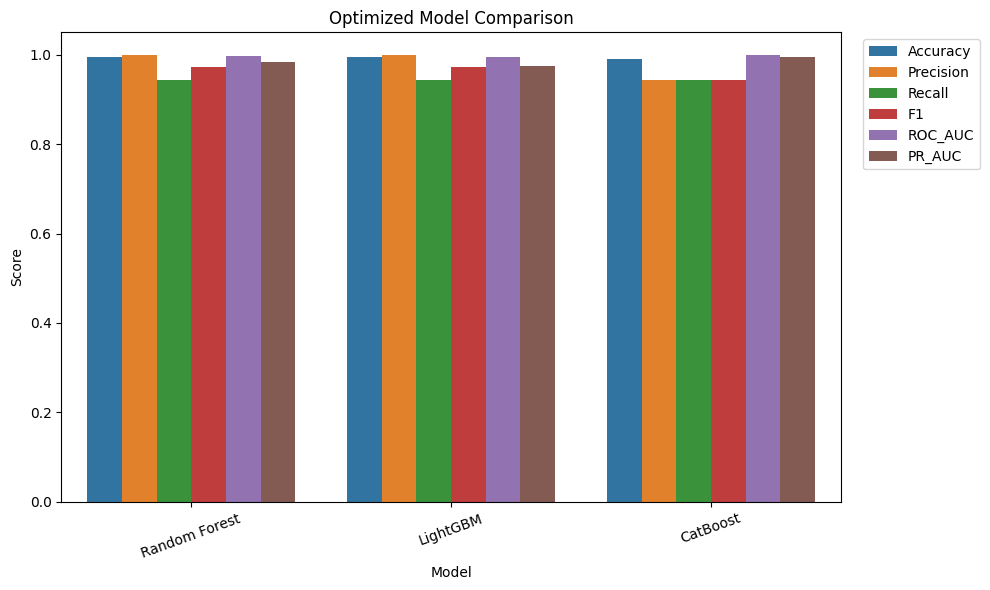

In [25]:
comparison_df = baseline_results.merge(
    optimization_results_df,
    on="Model",
    suffixes=("_Baseline", "_Optimized"),
    how="inner"
)

display(comparison_df)

comparison_df.to_csv(
    f"{RESULT_DIR}/baseline_vs_optimized.csv",
    index=False
)

plt.figure(figsize=(10, 6))

melted = optimization_results_df.melt(
    id_vars="Model",
    value_vars=["Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "PR_AUC"],
    var_name="Metric",
    value_name="Score"
)

sns.barplot(data=melted, x="Model", y="Score", hue="Metric")

plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.title("Optimized Model Comparison")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

plt.savefig(
    f"{FIGURE_DIR}/optimized_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [26]:
optimization_results_df.to_csv(
    f"{RESULT_DIR}/optimization_results.csv",
    index=False
)

params_df = pd.DataFrame(search_summaries)

params_df.to_csv(
    f"{RESULT_DIR}/optimization_parameters.csv",
    index=False
)

print("Optimization results and parameters saved.")

best_model_name = optimization_results_df.iloc[0]["Model"]

best_optimized_model = best_estimators[best_model_name]

joblib.dump(
    best_optimized_model,
    f"{MODEL_DIR}/best_optimized_model.pkl"
)

print(f"Best optimized model: {best_model_name}")
print(f"Saved to {MODEL_DIR}/best_optimized_model.pkl")

Optimization results and parameters saved.
Best optimized model: Random Forest
Saved to /content/drive/MyDrive/Ghana_Dropout_Project/models/best_optimized_model.pkl


,0
num__average_exam_score,0.107905
num__term_3_attendance,0.075282
num__term_1_attendance,0.071244
num__term_2_attendance,0.058888
num__math_exam_score,0.057061
cat__family_income_level_Low,0.050267
num__english_exam_score,0.049424
num__science_exam_score,0.048287
num__average_attendance,0.045609
cat__grade_repetition_count_2,0.035401


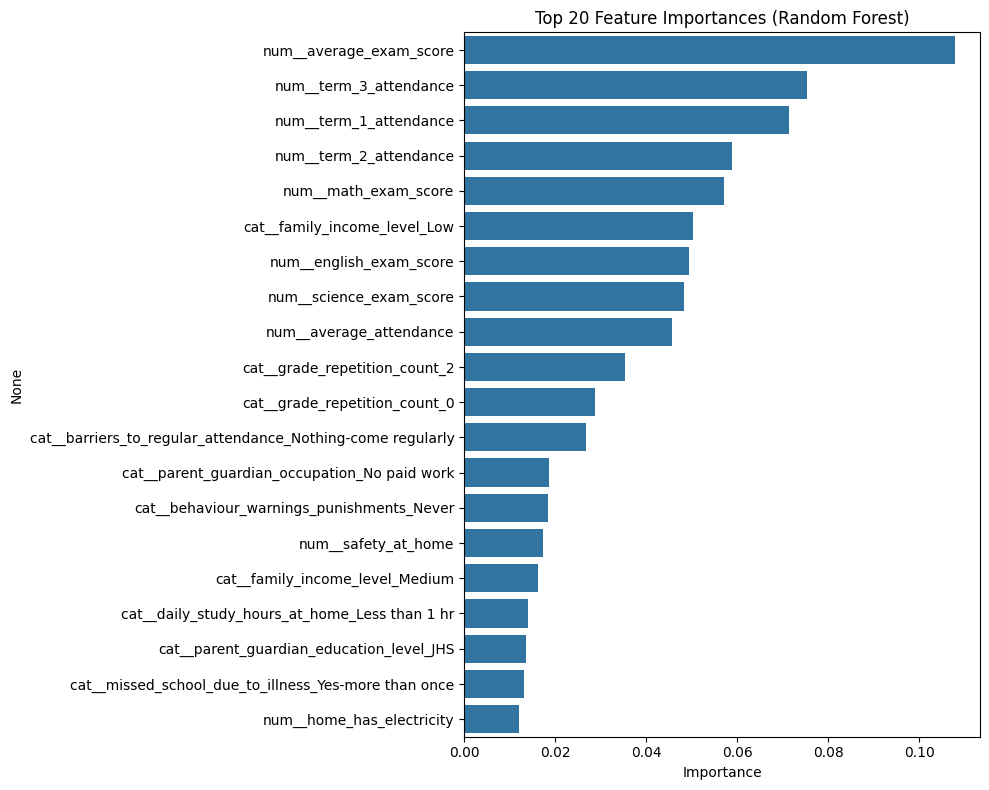

In [27]:
best_classifier = best_optimized_model.named_steps["classifier"]

feature_names = best_optimized_model.named_steps["preprocessor"].get_feature_names_out()

if hasattr(best_classifier, "feature_importances_"):

    importances = pd.Series(
        best_classifier.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)

    top_20 = importances.head(20)

    display(top_20)

    plt.figure(figsize=(10, 8))

    sns.barplot(x=top_20.values, y=top_20.index)

    plt.title(f"Top 20 Feature Importances ({best_model_name})")
    plt.xlabel("Importance")
    plt.tight_layout()

    plt.savefig(
        f"{FIGURE_DIR}/optimized_feature_importance.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

else:

    print(f"{best_model_name} does not expose feature_importances_.")


In [28]:
print("=" * 60)
print("NOTEBOOK 6 COMPLETE")
print("=" * 60)

print("Preprocessing pipeline saved: preprocessing_pipeline.pkl")
print("Train/test split saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv")
print("Optimization results saved: optimization_results.csv")
print("Search parameters saved: optimization_parameters.csv")
print(f"Best optimized model ({best_model_name}) saved: best_optimized_model.pkl")


NOTEBOOK 6 COMPLETE
Preprocessing pipeline saved: preprocessing_pipeline.pkl
Train/test split saved: X_train.csv, X_test.csv, y_train.csv, y_test.csv
Optimization results saved: optimization_results.csv
Search parameters saved: optimization_parameters.csv
Best optimized model (Random Forest) saved: best_optimized_model.pkl
